In [1]:
import os
import time
import numpy as np
import pandas as pd
import multiprocessing as mp
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import ParameterGrid

# ==========================================
# 1. CONFIGURACION Y CARGA DE DATOS (CNN)
# ==========================================

# Directorio de tu dataset
DATA_DIR = "../dataset_split"  # Ajusta esta ruta si es necesario
INPUT_SHAPE = (224, 224, 3)
BATCH_SIZE = 32

print("Iniciando proceso de extraccion de caracteristicas...")

# Definir el modelo base (MobileNetV2) sin la parte superior
base_model = MobileNetV2(weights='imagenet', 
                         include_top=False, 
                         input_shape=INPUT_SHAPE)
base_model.trainable = False

# Crear el extractor de caracteristicas
x = base_model.output
x = GlobalAveragePooling2D()(x)
feature_extractor = Model(inputs=base_model.input, outputs=x)

# Generadores de imagenes
datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = datagen.flow_from_directory(
    os.path.join(DATA_DIR, 'train'),
    target_size=(224, 224),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

val_generator = datagen.flow_from_directory(
    os.path.join(DATA_DIR, 'val'),
    target_size=(224, 224),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = datagen.flow_from_directory(
    os.path.join(DATA_DIR, 'test'),
    target_size=(224, 224),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Extraccion de caracteristicas
print("Extrayendo caracteristicas del set de entrenamiento...")
features_train = feature_extractor.predict(train_generator, verbose=1)
labels_train = train_generator.classes

print("Extrayendo caracteristicas del set de validacion...")
features_val = feature_extractor.predict(val_generator, verbose=1)
labels_val = val_generator.classes

print("Extrayendo caracteristicas del set de prueba...")
features_test = feature_extractor.predict(test_generator, verbose=1)
labels_test = test_generator.classes

# Guardado en CSV 
print("Guardando caracteristicas en CSV...")
pd.DataFrame(features_train).assign(label=labels_train).to_csv('../caracteristicas/train_features.csv', index=False)
pd.DataFrame(features_val).assign(label=labels_val).to_csv('../caracteristicas/val_features.csv', index=False)
pd.DataFrame(features_test).assign(label=labels_test).to_csv('../caracteristicas/test_features.csv', index=False)

# ==========================================
# 2. DEFINICION DE LA BUSQUEDA DE HIPERPARAMETROS
# ==========================================

# Preparar datos para sklearn
X_train = features_train
y_train = labels_train
X_val = features_val
y_val = labels_val
X_test = features_test
y_test = labels_test

# Grillas de hiperparametros (>16 combinaciones por modelo)
param_grids = {
    "svm": {
        'C': [0.1, 1, 10, 100, 1000],
        'kernel': ['rbf', 'poly', 'linear'],
        'gamma': ['scale', 'auto'] 
        # 30 combinaciones
    },
    "rf": {
        'n_estimators': [50, 100, 200, 300],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5],
        'criterion': ['gini', 'entropy']
        # 64 combinaciones
    },
    "knn": {
        'n_neighbors': [3, 5, 7, 9, 11, 15, 21, 31],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
        # 32 combinaciones
    }
}

def evaluate_configuration(args):
    """
    Entrena un modelo con una configuracion especifica y lo evalua en validacion.
    """
    model_name, params, X_tr, y_tr, X_v, y_v = args
    
    if model_name == "svm":
        clf = SVC(**params, random_state=42)
    elif model_name == "rf":
        # Importante: n_jobs=1 para evitar conflicto con multiprocessing
        clf = RandomForestClassifier(**params, random_state=42) 
    elif model_name == "knn":
        clf = KNeighborsClassifier(**params)
    
    start = time.time()
    clf.fit(X_tr, y_tr)
    preds = clf.predict(X_v)
    elapsed = time.time() - start
    
    acc = accuracy_score(y_v, preds)
    return (model_name, params, acc, elapsed)

def run_hyperparameter_search(n_processes=4):
    """
    Ejecuta la busqueda en paralelo.
    """
    all_tasks = []
    
    # Generar todas las tareas (Modelo + Combinacion de parametros)
    for model_name, grid in param_grids.items():
        combinations = list(ParameterGrid(grid))
        print(f"Preparando {len(combinations)} configuraciones para {model_name}...")
        for params in combinations:
            task = (model_name, params, X_train, y_train, X_val, y_val)
            all_tasks.append(task)
            
    print(f"Iniciando busqueda con {len(all_tasks)} tareas totales usando {n_processes} procesos...")
    
    start_total = time.time()
    
    # Ejecucion paralela
    with mp.Pool(processes=n_processes) as pool:
        results = pool.map(evaluate_configuration, all_tasks)
        
    end_total = time.time()
    print(f"Busqueda terminada en {end_total - start_total:.2f} segundos.")
    
    # Crear DataFrame con resultados
    df_res = pd.DataFrame(results, columns=["Model", "Params", "Accuracy", "Time"])
    return df_res

# ==========================================
# 3. EJECUCION Y SELECCION DEL MEJOR MODELO
# ==========================================

if __name__ == "__main__":
    # Ajusta n_processes segun tus nucleos disponibles
    df_results = run_hyperparameter_search(n_processes=8)
    
    print("\n=== MEJORES HIPERPARAMETROS EN VALIDACION ===")
    
    best_configs = {}
    
    for model in ["svm", "rf", "knn"]:
        # Filtrar por modelo y ordenar por accuracy descendente
        model_results = df_results[df_results["Model"] == model].sort_values(by="Accuracy", ascending=False)
        best_row = model_results.iloc[0]
        best_configs[model] = best_row['Params']
        
        print(f"\nModelo: {model.upper()}")
        print(f"  Accuracy (Val): {best_row['Accuracy']:.4f}")
        print(f"  Mejores Params: {best_row['Params']}")
        print(f"  Tiempo entrenamiento: {best_row['Time']:.4f} s")

    # ==========================================
    # 4. EVALUACION FINAL EN TEST (Entrenando con Train + Val)
    # ==========================================
    
    print("\n=== EVALUACION FINAL EN TEST SET ===")
    print("Entrenando modelos finales con los mejores hiperparametros (Train + Val)...")
    
    # Unir Train y Val para el entrenamiento final
    X_full_train = np.vstack([X_train, X_val])
    y_full_train = np.hstack([y_train, y_val])
    
    class_names = list(train_generator.class_indices.keys())
    
    # 1. Final SVM
    print("\n--- Final SVM ---")
    final_svm = SVC(**best_configs["svm"], random_state=42)
    final_svm.fit(X_full_train, y_full_train)
    preds_svm = final_svm.predict(X_test)
    print(f"Accuracy Test: {accuracy_score(y_test, preds_svm):.4f}")
    print(classification_report(y_test, preds_svm, target_names=class_names))
    
    # 2. Final Random Forest
    print("\n--- Final Random Forest ---")
    final_rf = RandomForestClassifier(**best_configs["rf"], random_state=42)
    final_rf.fit(X_full_train, y_full_train)
    preds_rf = final_rf.predict(X_test)
    print(f"Accuracy Test: {accuracy_score(y_test, preds_rf):.4f}")
    print(classification_report(y_test, preds_rf, target_names=class_names))
    
    # 3. Final KNN
    print("\n--- Final KNN ---")
    final_knn = KNeighborsClassifier(**best_configs["knn"])
    final_knn.fit(X_full_train, y_full_train)
    preds_knn = final_knn.predict(X_test)
    print(f"Accuracy Test: {accuracy_score(y_test, preds_knn):.4f}")
    print(classification_report(y_test, preds_knn, target_names=class_names))

2025-12-13 00:16:57.242332: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-13 00:16:57.281093: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-13 00:16:58.173945: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Iniciando proceso de extraccion de caracteristicas...


2025-12-13 00:17:04.608489: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Found 8783 images belonging to 3 classes.
Found 2509 images belonging to 3 classes.
Found 1258 images belonging to 3 classes.
Extrayendo caracteristicas del set de entrenamiento...
275/275 ━━━━━━━━━━━━━━━━━━━━ 80s 287ms/step 
Extrayendo caracteristicas del set de validacion...
79/79 ━━━━━━━━━━━━━━━━━━━━ 22s 279ms/step
Extrayendo caracteristicas del set de prueba...
40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 278ms/step
Guardando caracteristicas en CSV...
Preparando 30 configuraciones para svm...
Preparando 64 configuraciones para rf...
Preparando 32 configuraciones para knn...
Iniciando busqueda con 126 tareas totales usando 8 procesos...
Busqueda terminada en 649.99 segundos.

=== MEJORES HIPERPARAMETROS EN VALIDACION ===

Modelo: SVM
  Accuracy (Val): 0.9729
  Mejores Params: {'C': 10, 'gamma': 'scale', 'kernel': 'poly'}
  Tiempo entrenamiento: 41.9010 s

Modelo: RF
  Accuracy (Val): 0.9199
  Mejores Params: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}
  T

V2



In [2]:
# ==========================================
# SECCION 1: CONFIGURACION E IMPORTACIONES
# ==========================================
import os
import time
import numpy as np
import pandas as pd
import multiprocessing as mp
import tensorflow as tf

# Dependencias de Deep Learning
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Dependencias de Machine Learning
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

# Configuración de procesos
NUM_PROCESSES = 12  # 6 núcleos fisicos * 2 hilos = 12 procesos lógicos

# ==========================================
# SECCION 2: DEFINICION DEL EXTRACTOR DE CARACTERISTICAS (CNN)
# ==========================================
# 1. Define el tamaño de entrada
INPUT_SHAPE = (224, 224, 3)

# 2. Carga el modelo base
base_model = MobileNetV2(weights='imagenet', 
                         include_top=False, 
                         input_shape=INPUT_SHAPE)
base_model.trainable = False

# 3. Crea el extractor
x = base_model.output
x = GlobalAveragePooling2D()(x)
feature_extractor = Model(inputs=base_model.input, outputs=x)

# ==========================================
# SECCION 3: PREPARACION DE DATOS (GENERADORES)
# ==========================================
DATA_DIR = "../dataset_split"
TARGET_SIZE = (224, 224)
BATCH_SIZE = 32

datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = datagen.flow_from_directory(
    os.path.join(DATA_DIR, 'train'),
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

val_generator = datagen.flow_from_directory(
    os.path.join(DATA_DIR, 'val'),
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = datagen.flow_from_directory(
    os.path.join(DATA_DIR, 'test'),
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# ==========================================
# SECCION 4: EXTRACCION DE CARACTERISTICAS
# ==========================================
print("\n=== EXTRACCION DE CARACTERISTICAS ===")
print("Extrayendo características del set de entrenamiento...")
features_train = feature_extractor.predict(train_generator, verbose=1)
labels_train = train_generator.classes

print("Extrayendo características del set de validación...")
features_val = feature_extractor.predict(val_generator, verbose=1)
labels_val = val_generator.classes

print("Extrayendo características del set de prueba...")
features_test = feature_extractor.predict(test_generator, verbose=1)
labels_test = test_generator.classes

# ==========================================
# SECCION 5: GUARDADO DE DATOS (CSV)
# ==========================================
# (Opcional, útil para no repetir la extracción si se reinicia)
df_train = pd.DataFrame(features_train)
df_train['label'] = labels_train
df_train.to_csv('../caracteristicas/train_features.csv', index=False)

df_test = pd.DataFrame(features_test)
df_test['label'] = labels_test
df_test.to_csv('../caracteristicas/test_features.csv', index=False)

# ==========================================
# SECCION 6: PREPARACION PARA MACHINE LEARNING
# ==========================================
X_train = features_train
y_train = labels_train
X_test  = features_test
y_test  = labels_test

# ==========================================
# SECCION 7: BUSQUEDA DE HIPERPARAMETROS (GRID SEARCH CON MULTIPROCESSING)
# ==========================================
print(f"\n=== INICIANDO BUSQUEDA DE HIPERPARAMETROS CON {NUM_PROCESSES} PROCESOS ===")

# 1. Definir los espacios de búsqueda para cada modelo
param_grids = {
    "SVM": {
        "estimator": SVC(),
        "params": {
            'C': [0.1, 1, 10, 100],
            'kernel': ['rbf', 'linear'],
            'gamma': ['scale', 'auto']
        }
    },
    "Random Forest": {
        "estimator": RandomForestClassifier(random_state=42),
        "params": {
            'n_estimators': [50, 100, 200],
            'max_depth': [None, 10, 20],
            'min_samples_split': [2, 5]
        }
    },
    "KNN": {
        "estimator": KNeighborsClassifier(),
        "params": {
            'n_neighbors': [3, 5, 7, 9, 11],
            'weights': ['uniform', 'distance'],
            'metric': ['euclidean', 'manhattan']
        }
    }
}

best_estimators = {}

for model_name, config in param_grids.items():
    print(f"\n---> Buscando mejores parámetros para: {model_name} ...")
    
    # Configurar GridSearchCV
    # n_jobs=NUM_PROCESSES habilita el uso de todos los núcleos lógicos (12 en tu caso)
    grid_search = GridSearchCV(
        estimator=config["estimator"],
        param_grid=config["params"],
        cv=3,              # Validación cruzada de 3 pliegues
        n_jobs=NUM_PROCESSES, 
        verbose=1,         # Muestra progreso
        scoring='accuracy'
    )
    
    # Ejecutar búsqueda y medir tiempo
    start_time = time.time()
    grid_search.fit(X_train, y_train)
    end_time = time.time()
    
    # Guardar el mejor modelo entrenado
    best_estimators[model_name] = grid_search.best_estimator_
    
    # --- REPORTE DE LA BÚSQUEDA ---
    print(f"    Tiempo de búsqueda: {end_time - start_time:.2f} segundos")
    print(f"    Mejores Hiperparámetros encontrados: {grid_search.best_params_}")
    print(f"    Mejor Accuracy (Cross-Validation): {grid_search.best_score_:.4f}")
    
    print(f"    Desempeño con diferentes configuraciones (Top 5):")
    results = pd.DataFrame(grid_search.cv_results_)
    results = results.sort_values(by='rank_test_score')
    for i, row in results.head(5).iterrows():
        print(f"      - Params: {row['params']} | Acc: {row['mean_test_score']:.4f}")

# ==========================================
# SECCION 8: EVALUACION FINAL EN TEST
# ==========================================
print("\n=== EVALUACION FINAL EN EL SET DE PRUEBA (MEJORES MODELOS) ===")

class_names = list(train_generator.class_indices.keys())

for model_name, model in best_estimators.items():
    print(f"\n--- Reporte Final: {model_name} ---")
    
    # Predecir usando el mejor modelo encontrado
    y_pred = model.predict(X_test)
    
    # Calcular métricas
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy Final (Test): {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=class_names))

# ==========================================
# SECCION 9: VERIFICACION DE SOBREAJUSTE (OVERFITTING)
# ==========================================
print("\n=== VERIFICACION DE SOBREAJUSTE ===")

for model_name, model in best_estimators.items():
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    
    diff = train_acc - test_acc
    print(f"\nModelo: {model_name}")
    print(f"  Accuracy Train: {train_acc:.4f}")
    print(f"  Accuracy Test:  {test_acc:.4f}")
    print(f"  Diferencia:     {diff:.4f}")
    
    if diff > 0.10:
        print("  [ALERTA] Posible sobreajuste significativo (>10%)")
    elif diff > 0.05:
        print("  [ATENCION] Ligero sobreajuste (>5%)")
    else:
        print("  [OK] Generalización correcta")

Found 8783 images belonging to 3 classes.
Found 2509 images belonging to 3 classes.
Found 1258 images belonging to 3 classes.

=== EXTRACCION DE CARACTERISTICAS ===
Extrayendo características del set de entrenamiento...
275/275 ━━━━━━━━━━━━━━━━━━━━ 79s 284ms/step 
Extrayendo características del set de validación...
79/79 ━━━━━━━━━━━━━━━━━━━━ 22s 279ms/step
Extrayendo características del set de prueba...
40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 277ms/step

=== INICIANDO BUSQUEDA DE HIPERPARAMETROS CON 12 PROCESOS ===

---> Buscando mejores parámetros para: SVM ...
Fitting 3 folds for each of 16 candidates, totalling 48 fits
    Tiempo de búsqueda: 227.91 segundos
    Mejores Hiperparámetros encontrados: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
    Mejor Accuracy (Cross-Validation): 0.9155
    Desempeño con diferentes configuraciones (Top 5):
      - Params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'} | Acc: 0.9155
      - Params: {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'} | Acc: 0.9152
  

## Visualizacion


In [3]:
# ==========================================
# SECCION 1: CONFIGURACION E IMPORTACIONES
# ==========================================
import os
import time
import numpy as np
import pandas as pd
import multiprocessing as mp
import tensorflow as tf

# Dependencias de Deep Learning
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Dependencias de Machine Learning
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

# Configuración de procesos (12 hilos lógicos)
NUM_PROCESSES = 12 

# ==========================================
# SECCION 2: DEFINICION DEL EXTRACTOR DE CARACTERISTICAS (CNN)
# ==========================================
INPUT_SHAPE = (224, 224, 3)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=INPUT_SHAPE)
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
feature_extractor = Model(inputs=base_model.input, outputs=x)

# ==========================================
# SECCION 3: PREPARACION DE DATOS
# ==========================================
DATA_DIR = "../dataset_split"
TARGET_SIZE = (224, 224)
BATCH_SIZE = 32

datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = datagen.flow_from_directory(
    os.path.join(DATA_DIR, 'train'),
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)
# (Val y Test se cargan igual, asumimos la estructura estándar)
val_generator = datagen.flow_from_directory(
    os.path.join(DATA_DIR, 'val'),
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)
test_generator = datagen.flow_from_directory(
    os.path.join(DATA_DIR, 'test'),
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# ==========================================
# SECCION 4: EXTRACCION DE CARACTERISTICAS
# ==========================================
print("\n=== EXTRACCION DE CARACTERISTICAS ===")
features_train = feature_extractor.predict(train_generator, verbose=1)
labels_train = train_generator.classes

features_test = feature_extractor.predict(test_generator, verbose=1)
labels_test = test_generator.classes

X_train, y_train = features_train, labels_train
X_test, y_test = features_test, labels_test

# ==========================================
# SECCION 5: BUSQUEDA DE HIPERPARAMETROS
# ==========================================
print(f"\n=== INICIANDO BUSQUEDA CON {NUM_PROCESSES} PROCESOS ===")

param_grids = {
    "SVM": {
        "estimator": SVC(),
        "params": {
            'C': [0.1, 1, 10, 100],
            'kernel': ['rbf', 'linear'],
            'gamma': ['scale', 'auto']
        }
    },
    "Random Forest": {
        "estimator": RandomForestClassifier(random_state=42),
        "params": {
            'n_estimators': [50, 100, 200],
            'max_depth': [10, 20, None],
            'min_samples_split': [2, 5]
        }
    },
    "KNN": {
        "estimator": KNeighborsClassifier(),
        "params": {
            'n_neighbors': [3, 5, 7, 9, 11],
            'weights': ['uniform', 'distance'],
            'metric': ['euclidean', 'manhattan']
        }
    }
}

best_estimators = {}
history_results = {} 

for model_name, config in param_grids.items():
    print(f"\n---> Optimizando: {model_name} ...")
    
    grid_search = GridSearchCV(
        estimator=config["estimator"],
        param_grid=config["params"],
        cv=3,
        n_jobs=NUM_PROCESSES, # Paralelización
        verbose=1,
        scoring='accuracy'
    )
    
    start_time = time.time()
    grid_search.fit(X_train, y_train)
    end_time = time.time()
    
    # Guardar resultados
    best_estimators[model_name] = grid_search.best_estimator_
    history_results[model_name] = pd.DataFrame(grid_search.cv_results_) # Guardamos el DataFrame completo
    
    print(f"    Tiempo: {end_time - start_time:.2f}s | Mejor Acc: {grid_search.best_score_:.4f}")

print("\n¡Búsqueda completada! Ejecuta la siguiente celda para ver las gráficas comparativas.")

Found 8783 images belonging to 3 classes.
Found 2509 images belonging to 3 classes.
Found 1258 images belonging to 3 classes.

=== EXTRACCION DE CARACTERISTICAS ===
275/275 ━━━━━━━━━━━━━━━━━━━━ 77s 277ms/step 
40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 274ms/step

=== INICIANDO BUSQUEDA CON 12 PROCESOS ===

---> Optimizando: SVM ...
Fitting 3 folds for each of 16 candidates, totalling 48 fits
    Tiempo: 211.14s | Mejor Acc: 0.9155

---> Optimizando: Random Forest ...
Fitting 3 folds for each of 18 candidates, totalling 54 fits
    Tiempo: 155.42s | Mejor Acc: 0.8511

---> Optimizando: KNN ...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
    Tiempo: 93.33s | Mejor Acc: 0.8615

¡Búsqueda completada! Ejecuta la siguiente celda para ver las gráficas comparativas.


=== ANALISIS DE HIPERPARAMETROS VS ACCURACY ===


------------------------------------------------
 MODELO: SVM
------------------------------------------------
Top 5 Configuraciones:
 mean_test_score  std_test_score                                        params
        0.915510        0.052703  {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
        0.915169        0.052631 {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
        0.911753        0.051232   {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
        0.911298        0.051779  {'C': 100, 'gamma': 'auto', 'kernel': 'rbf'}
        0.903101        0.051523   {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}


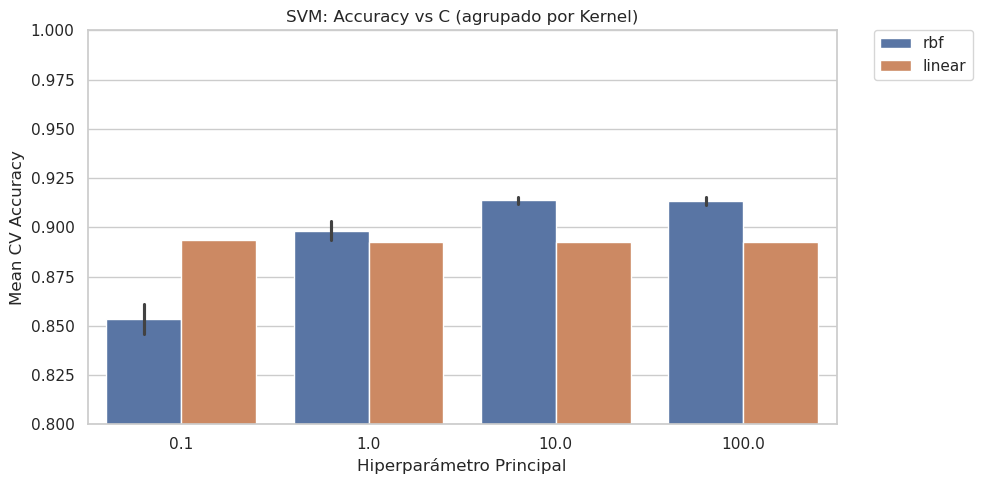


------------------------------------------------
 MODELO: Random Forest
------------------------------------------------
Top 5 Configuraciones:
 mean_test_score  std_test_score                                                           params
        0.851068        0.056215   {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
        0.850613        0.056223 {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
        0.850157        0.058629   {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}
        0.847880        0.057482 {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
        0.846856        0.053213   {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}


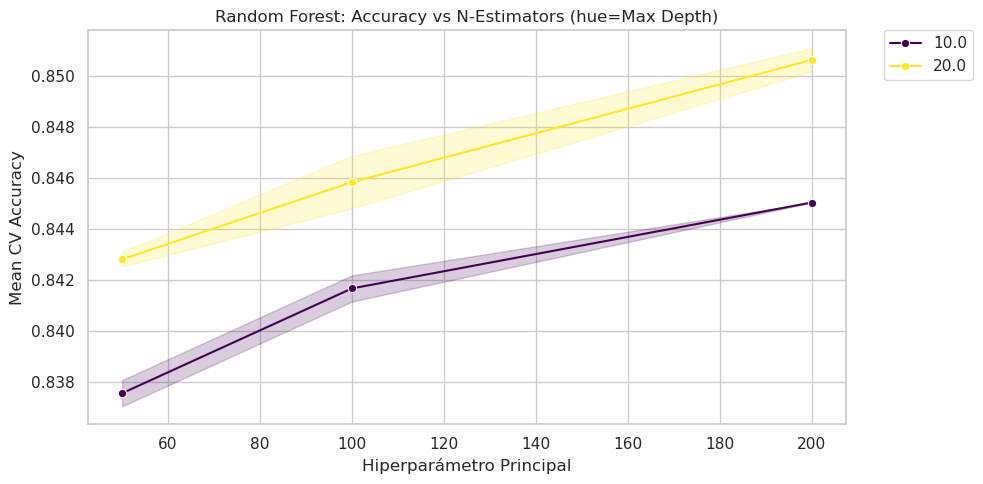


------------------------------------------------
 MODELO: KNN
------------------------------------------------
Top 5 Configuraciones:
 mean_test_score  std_test_score                                                           params
        0.861544        0.047411 {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
        0.860405        0.050148 {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
        0.860177        0.052039  {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
        0.859608        0.051002 {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'distance'}
        0.859495        0.046509  {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}


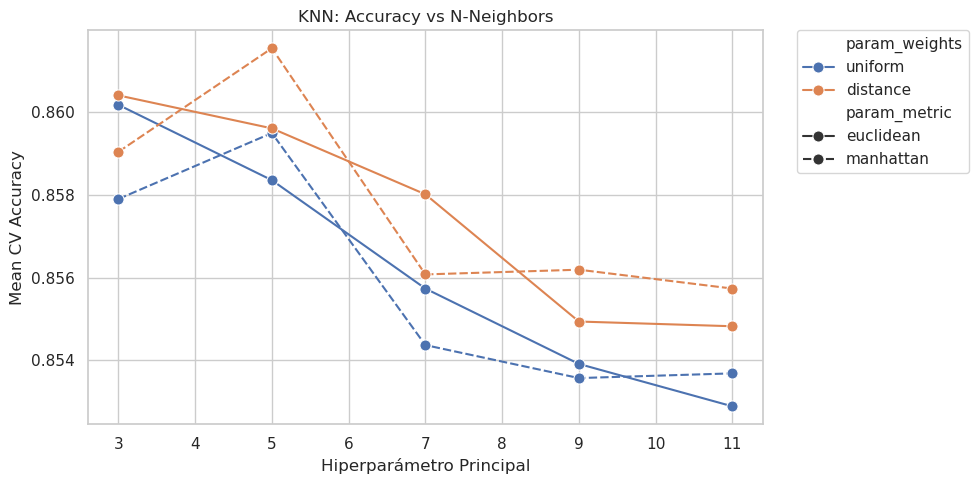

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set(style="whitegrid")

print("=== ANALISIS DE HIPERPARAMETROS VS ACCURACY ===\n")

for model_name, df_results in history_results.items():
    print(f"\n------------------------------------------------")
    print(f" MODELO: {model_name}")
    print(f"------------------------------------------------")
    
    # Ordenamos por score para ver los mejores arriba
    df_sorted = df_results.sort_values(by='mean_test_score', ascending=False)
    
    # 1. MOSTRAR TABLA TOP 5
    print("Top 5 Configuraciones:")
    # Seleccionamos columnas relevantes (params + score)
    cols_to_show = ['mean_test_score', 'std_test_score', 'params']
    print(df_sorted[cols_to_show].head(5).to_string(index=False))
    
    # 2. GRAFICAR LAS DIFERENCIAS
    plt.figure(figsize=(10, 5))
    
    if model_name == "SVM":
        # Grafico para SVM: Impacto de C y Kernel
        # Creamos una columna combinada para el eje X
        df_results['param_C'] = df_results['param_C'].astype(str)
        sns.barplot(x='param_C', y='mean_test_score', hue='param_kernel', data=df_results)
        plt.title(f"{model_name}: Accuracy vs C (agrupado por Kernel)")
        plt.ylim(0.8, 1.0) # Ajustar límites para ver mejor las diferencias finas
        
    elif model_name == "Random Forest":
        # Grafico para RF: Impacto de n_estimators y max_depth
        sns.lineplot(x='param_n_estimators', y='mean_test_score', hue='param_max_depth', 
                     data=df_results, marker='o', palette="viridis")
        plt.title(f"{model_name}: Accuracy vs N-Estimators (hue=Max Depth)")
        
    elif model_name == "KNN":
        # Grafico para KNN: Impacto de n_neighbors y weights
        sns.lineplot(x='param_n_neighbors', y='mean_test_score', hue='param_weights', 
                     style='param_metric', data=df_results, marker='o', markersize=8)
        plt.title(f"{model_name}: Accuracy vs N-Neighbors")
    
    plt.ylabel("Mean CV Accuracy")
    plt.xlabel("Hiperparámetro Principal")
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
    plt.tight_layout()
    plt.show()

# Configuracion Grad-Cam

In [20]:
# ==========================================
# BLOQUE 1: CONFIGURACION GRADCAM + LOG
# ==========================================

from collections import Counter
from concurrent.futures import ThreadPoolExecutor, as_completed
from collections import Counter

GRADCAM_DIR = "../results/gradcam"
os.makedirs(GRADCAM_DIR, exist_ok=True)

LAST_CONV_LAYER = "Conv_1"

In [21]:
# ==========================================
# BLOQUE 2: MODELO GRADCAM
# ==========================================

gradcam_model = Model(
    inputs=base_model.input,
    outputs=[
        base_model.get_layer(LAST_CONV_LAYER).output,
        base_model.output
    ]
)

# Procesamiento Imagen

In [22]:
# ==========================================
# BLOQUE 3: FUNCION GRADCAM
# ==========================================

def compute_gradcam(image_array, class_index):
    with tf.GradientTape() as tape:
        conv_outputs, predictions = gradcam_model(image_array)
        loss = predictions[:, class_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    heatmap = tf.reduce_sum(conv_outputs[0] * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + 1e-8

    return heatmap.numpy()

In [32]:
# ==========================================
# BLOQUE 4: WORKER CON LOG
# ==========================================

import matplotlib.cm as cm

def process_single_image_thread(img_path, label, class_name):
    tid = threading.get_ident()

    # ===== Cargar imagen original =====
    img = tf.keras.preprocessing.image.load_img(
        img_path, target_size=(224, 224)
    )
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array_pre = preprocess_input(img_array.copy())
    img_array_pre = np.expand_dims(img_array_pre, axis=0)

    # ===== Grad-CAM =====
    heatmap = compute_gradcam(img_array_pre, label)

    heatmap = tf.image.resize(
        heatmap[..., np.newaxis], (224, 224)
    ).numpy().squeeze()

    heatmap = np.clip(heatmap, 0, 1)

    # ===== Aplicar colormap (JET) =====
    colormap = cm.get_cmap("jet")
    heatmap_color = colormap(heatmap)[:, :, :3]  # Quitar alpha

    heatmap_color = np.uint8(255 * heatmap_color)

    # ===== Superponer con imagen original =====
    overlay = 0.4 * heatmap_color + 0.6 * img_array
    overlay = np.clip(overlay, 0, 255).astype(np.uint8)

    # ===== Guardado =====
    out_dir = os.path.join(GRADCAM_DIR, class_name)
    os.makedirs(out_dir, exist_ok=True)

    out_path = os.path.join(out_dir, os.path.basename(img_path))
    tf.keras.preprocessing.image.save_img(out_path, overlay)

    return tid, os.path.basename(img_path)


In [33]:
# ==========================================
# BLOQUE 5: MONITOR DE PROGRESO
# ==========================================

def monitor_progress(queue, total):
    processed = 0
    worker_log = []

    while processed < total:
        pid, msg = queue.get()
        processed += 1
        worker_log.append(pid)

        print(f"[PID {pid}] {processed}/{total} -> {msg}")

    print("\n=== RESUMEN POR PROCESO ===")
    for pid, count in Counter(worker_log).items():
        print(f"PID {pid}: {count} imágenes")

# Test

In [34]:
# ==========================================
# BLOQUE 6: PREPARACION DE TAREAS
# ==========================================

test_image_paths = test_generator.filepaths
test_labels = test_generator.classes
class_names = list(test_generator.class_indices.keys())

tasks = [
    (path, label, class_names[label], None)
    for path, label in zip(test_image_paths, test_labels)
]

In [35]:
import threading

tasks = [
    (path, label, class_names[label])
    for path, label in zip(test_image_paths, test_labels)
]

print(f"Procesando {len(tasks)} imágenes con threading...\n")

start_time = time.time()
worker_log = []

with ThreadPoolExecutor(max_workers=8) as executor:
    futures = {
        executor.submit(process_single_image_thread, *task): task
        for task in tasks
    }

    for i, future in enumerate(as_completed(futures), 1):
        tid, img_name = future.result()
        worker_log.append(tid)
        print(f"[Thread {tid}] {i}/{len(tasks)} -> {img_name}")

end_time = time.time()

print(f"\nGrad-CAM completado en {end_time - start_time:.2f} segundos")

Procesando 1258 imágenes con threading...



/tmp/ipykernel_44137/2225105649.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap("jet")


[Thread 135701672736448] 1/1258 -> 1120.png
[Thread 135700993799872] 2/1258 -> 107.png
[Thread 135701689525952] 3/1258 -> 111.png
[Thread 135701697918656] 4/1258 -> 1039.png
[Thread 135707706861248] 5/1258 -> 1091.png
[Thread 135701681129152] 6/1258 -> 1072.png
[Thread 135705047070400] 7/1258 -> 1020.png
[Thread 135705038677696] 8/1258 -> 1092.png
[Thread 135701672736448] 9/1258 -> 1125.png
[Thread 135700993799872] 10/1258 -> 1134.png
[Thread 135701689525952] 11/1258 -> 1141.png
[Thread 135701681129152] 12/1258 -> 1163.png
[Thread 135701697918656] 13/1258 -> 1145.png
[Thread 135707706861248] 14/1258 -> 1160.png
[Thread 135705038677696] 15/1258 -> 1185.png
[Thread 135705047070400] 16/1258 -> 1181.png
[Thread 135700993799872] 17/1258 -> 1188.png
[Thread 135705038677696] 18/1258 -> 1245.png
[Thread 135705047070400] 19/1258 -> 125.png
[Thread 135701672736448] 20/1258 -> 1186.png
[Thread 135707706861248] 21/1258 -> 1243.png
[Thread 135701681129152] 22/1258 -> 1197.png
[Thread 13570169791865

In [36]:
print("\n=== RESUMEN POR THREAD ===")
for tid, count in Counter(worker_log).items():
    print(f"Thread {tid}: {count} imágenes")



=== RESUMEN POR THREAD ===
Thread 135701672736448: 157 imágenes
Thread 135700993799872: 157 imágenes
Thread 135701689525952: 157 imágenes
Thread 135701697918656: 158 imágenes
Thread 135707706861248: 158 imágenes
Thread 135701681129152: 157 imágenes
Thread 135705047070400: 157 imágenes
Thread 135705038677696: 157 imágenes
